In [1]:
!pip install sqlalchemy pymysql pandas seaborn matplotlib scipy python-dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from scipy import stats

%matplotlib inline
sns.set(style="whitegrid")


In [5]:
DB_HOST= "shtm-fallprev.mysql.database.azure.com"
DB_USER= "ahistudent"
DB_PASSWORD= "researcher"
DB_NAME= "sbu_athletics"
DB_TABLE= "research_experiment_refactor_test"

connection_url = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}"
engine = create_engine(connection_url)

# Test: pull a few rows just to confirm
test_df = pd.read_sql(f"SELECT * FROM {DB_TABLE} LIMIT 5", engine)
test_df

,id,playername,timestamp,device,metric,value,team,session_type,session_description,function_description,data_source,created_at
0,1,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Force(N),1546.3816,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
1,2,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Power(W),-1099.2175,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
2,3,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Braking Velocity(m/s),-0.7630,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
3,4,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Landing Force(N),1251.3600,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54
4,5,PLAYER_1175,2018-10-15 19:27:41,hawkins,Avg. Propulsive Force(N),1887.0421,Team: Stony Brook,None,None,None,hawkins,2025-10-21 16:46:54


In [7]:
query_teams_bball = f"""
SELECT DISTINCT team
FROM {DB_TABLE}
WHERE team LIKE '%%Basketball%%'
ORDER BY team;
"""

teams_bball = pd.read_sql(query_teams_bball, engine)
teams_bball

,team
0,"Group: 2023-2024 WBB, Group: Women's Basketbal..."
1,"Group: 21-22, Team: Stony Brook Men's Basketball"
2,"Group: Men's Basketball, Group: 21-22, Team: S..."
3,"Group: Men's Basketball, Group: 21-22, Team: S..."
4,"Group: Men's Basketball, Group: Men's Basketba..."
5,"Group: Men's Basketball, Team: Stony Brook"
6,"Group: Men's Basketball, Team: Stony Brook Men..."
7,"Group: msoc, Group: 2023-2024 WBB, Group: Wome..."
8,"Group: msoc, Team: Stony Brook Women's Basketball"
9,"Group: Women's Basketball, Group: 2023-2024 WB..."


In [9]:
metric_list = (
    "'accel_load_accum', "
    "'distance_total', "
    "'Jump Height(m)', "
    "'Peak Propulsive Force(N)', "
    "'RSI'"
)

query_team_counts = f"""
SELECT team, COUNT(*) AS num_rows
FROM {DB_TABLE}
WHERE metric IN ({metric_list})
GROUP BY team
ORDER BY num_rows DESC
LIMIT 14;
"""

team_metric_counts = pd.read_sql(query_team_counts, engine)
team_metric_counts


,team,num_rows
0,Mens Basketball,18448
1,Football,18368
2,Womens Basketball,16790
3,Womens Soccer,16241
4,Mens Soccer,11759
5,"Group: WLAX , Group: WLAX Spring '24, Team: SB...",8654
6,Team: Stony Brook Womens Soccer,7005
7,"Group: 2023-2024 WBB, Group: Women's Basketbal...",6109
8,Team: Stony Brook Swimming and Diving,6061
9,Team: Stony Brook MLAX,4608


In [25]:
print("Rows per metric:")
display(df["metric"].value_counts())

print("\nRows per metric per team:")
display(df.groupby(["metric", "team"]).size())


Rows per metric:


,count
metric,
Jump Height(m),1533
Peak Propulsive Force(N),1533
RSI,1530



Rows per metric per team:


metric                    team                                
Jump Height(m)            Team: Stony Brook Men's Basketball      920
                          Team: Stony Brook Women's Basketball    613
Peak Propulsive Force(N)  Team: Stony Brook Men's Basketball      920
                          Team: Stony Brook Women's Basketball    613
RSI                       Team: Stony Brook Men's Basketball      917
                          Team: Stony Brook Women's Basketball    613
dtype: int64

In [26]:
# All known labels for these teams across systems

TEAM_A_LABELS = [
    "Team: Stony Brook Men's Basketball",  # Hawkins
    "Mens Basketball"                      # Kinexon
]

TEAM_B_LABELS = [
    "Team: Stony Brook Women's Basketball",  # Hawkins
    "Womens Basketball"                      # Kinexon
]

ALL_TEAM_LABELS = TEAM_A_LABELS + TEAM_B_LABELS
ALL_TEAM_LABELS


["Team: Stony Brook Men's Basketball",
 'Mens Basketball',
 "Team: Stony Brook Women's Basketball",
 'Womens Basketball']

In [27]:
METRICS = [
    "accel_load_accum",
    "distance_total",
    "Jump Height(m)",
    "Peak Propulsive Force(N)",
    "RSI"
]

# Placeholders for metrics and team names
metric_placeholders = ",".join(["%s"] * len(METRICS))
team_placeholders = ",".join(["%s"] * len(ALL_TEAM_LABELS))

query_data = """
SELECT playername, team, timestamp, metric, value
FROM {table}
WHERE metric IN ({metric_placeholders})
  AND team IN ({team_placeholders})
  AND value IS NOT NULL
""".format(
    table=DB_TABLE,
    metric_placeholders=metric_placeholders,
    team_placeholders=team_placeholders
)

params = tuple(METRICS + ALL_TEAM_LABELS)

df = pd.read_sql(query_data, engine, params=params)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df.head(), len(df)


(   playername               team           timestamp            metric  \
 0  PLAYER_038    Mens Basketball 2021-06-17 21:49:39  accel_load_accum   
 1  PLAYER_038    Mens Basketball 2021-06-18 21:18:02  accel_load_accum   
 2  PLAYER_454  Womens Basketball 2021-06-21 14:23:09  accel_load_accum   
 3  PLAYER_751  Womens Basketball 2021-06-21 14:23:09  accel_load_accum   
 4  PLAYER_905  Womens Basketball 2021-06-21 14:23:09  accel_load_accum   
 
         value  
 0   14.937311  
 1  128.858592  
 2  450.760647  
 3  385.119048  
 4  610.039010  ,
 39834)

In [29]:
# Normalize team names to clean labels for analysis

def clean_team(name):
    name = name.strip()  # remove leading/trailing spaces

    # Men
    if "Men" in name and "Basketball" in name:
        return "Men's Basketball"

    # Women
    if "Wom" in name and "Basketball" in name:
        return "Women's Basketball"

    # Fallback: return original (shouldn't happen)
    return name

df["team_clean"] = df["team"].apply(clean_team)

df[["team", "team_clean"]].drop_duplicates()


,team,team_clean
0,Mens Basketball,Men's Basketball
2,Womens Basketball,Women's Basketball
35238,Team: Stony Brook Women's Basketball,Women's Basketball
35250,Team: Stony Brook Men's Basketball,Men's Basketball


In [30]:
print("Rows per metric:")
display(df["metric"].value_counts())

print("\nRows per metric per clean team:")
display(df.groupby(["metric", "team_clean"]).size())


Rows per metric:


,count
metric,
accel_load_accum,17619
distance_total,17619
Jump Height(m),1533
Peak Propulsive Force(N),1533
RSI,1530



Rows per metric per clean team:


metric                    team_clean        
Jump Height(m)            Men's Basketball       920
                          Women's Basketball     613
Peak Propulsive Force(N)  Men's Basketball       920
                          Women's Basketball     613
RSI                       Men's Basketball       917
                          Women's Basketball     613
accel_load_accum          Men's Basketball      9224
                          Women's Basketball    8395
distance_total            Men's Basketball      9224
                          Women's Basketball    8395
dtype: int64


Metric: accel_load_accum
Rows for this metric: 17619


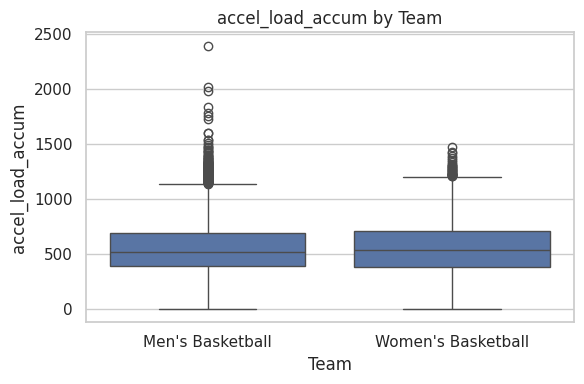

Samples for Men's Basketball: 9224
Samples for Women's Basketball: 8395
t-statistic: -2.83537950764231
p-value   : 0.004582353844008908

Metric: distance_total
Rows for this metric: 17619


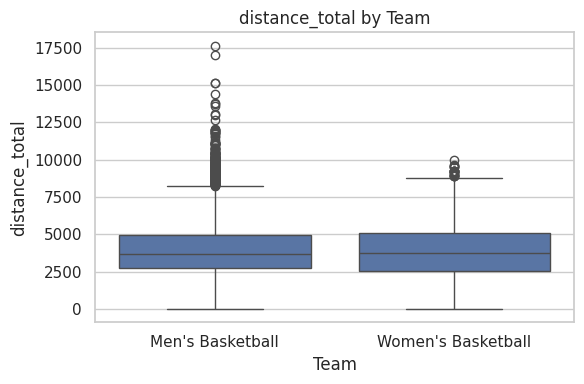

Samples for Men's Basketball: 9224
Samples for Women's Basketball: 8395
t-statistic: 1.6259024101388189
p-value   : 0.10398830414748231

Metric: Jump Height(m)
Rows for this metric: 1533


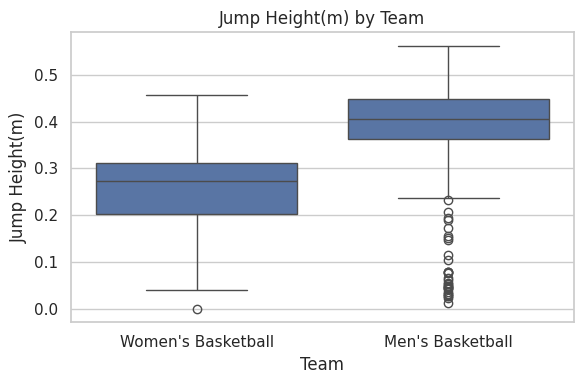

Samples for Men's Basketball: 920
Samples for Women's Basketball: 613
t-statistic: 34.772293380154245
p-value   : 1.6447483596524628e-190

Metric: Peak Propulsive Force(N)
Rows for this metric: 1533


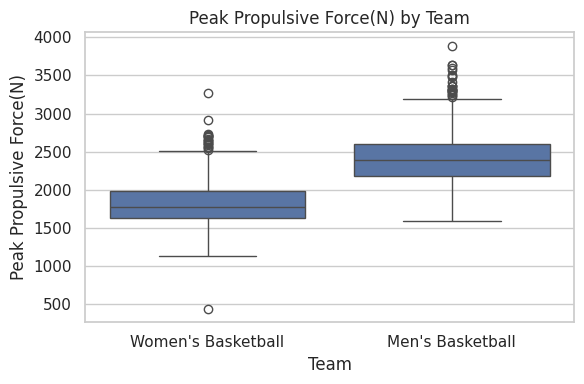

Samples for Men's Basketball: 920
Samples for Women's Basketball: 613
t-statistic: 35.38584367728158
p-value   : 6.375321507760857e-194

Metric: RSI
Rows for this metric: 1530


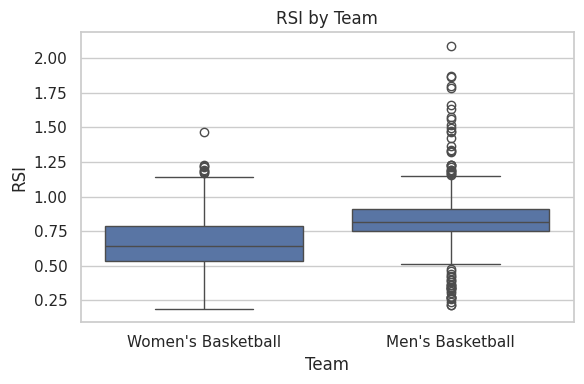

Samples for Men's Basketball: 917
Samples for Women's Basketball: 613
t-statistic: 18.123894622219066
p-value   : 1.5382541519022726e-65


In [31]:
for metric in METRICS:
    print("\n==============================")
    print("Metric:", metric)

    sub = df[df["metric"] == metric].copy()
    print("Rows for this metric:", len(sub))

    # skip if no data
    if sub.empty:
        print("No data for this metric for these teams. Skipping.")
        continue

    # ----- Box Plot -----
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=sub, x="team_clean", y="value")
    plt.title(f"{metric} by Team")
    plt.xlabel("Team")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

    # ----- T-Test -----
    values_a = sub[sub["team_clean"] == "Men's Basketball"]["value"].dropna()
    values_b = sub[sub["team_clean"] == "Women's Basketball"]["value"].dropna()

    print(f"Samples for Men's Basketball: {len(values_a)}")
    print(f"Samples for Women's Basketball: {len(values_b)}")

    if len(values_a) > 1 and len(values_b) > 1:
        t_stat, p_value = stats.ttest_ind(values_a, values_b, equal_var=False)
        print("t-statistic:", t_stat)
        print("p-value   :", p_value)
    else:
        print("Not enough data for t-test.")


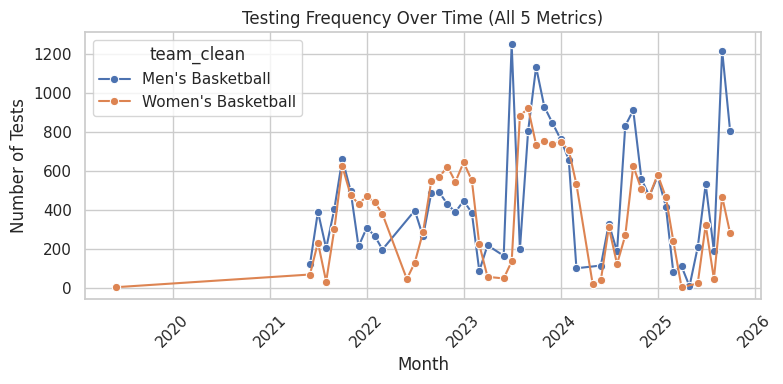

In [32]:
df["month"] = df["timestamp"].dt.to_period("M").dt.to_timestamp()

freq = (
    df.groupby(["team_clean", "month"])
      .size()
      .reset_index(name="num_tests")
)

plt.figure(figsize=(8, 4))
sns.lineplot(data=freq, x="month", y="num_tests", hue="team_clean", marker="o")
plt.title("Testing Frequency Over Time (All 5 Metrics)")
plt.xlabel("Month")
plt.ylabel("Number of Tests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


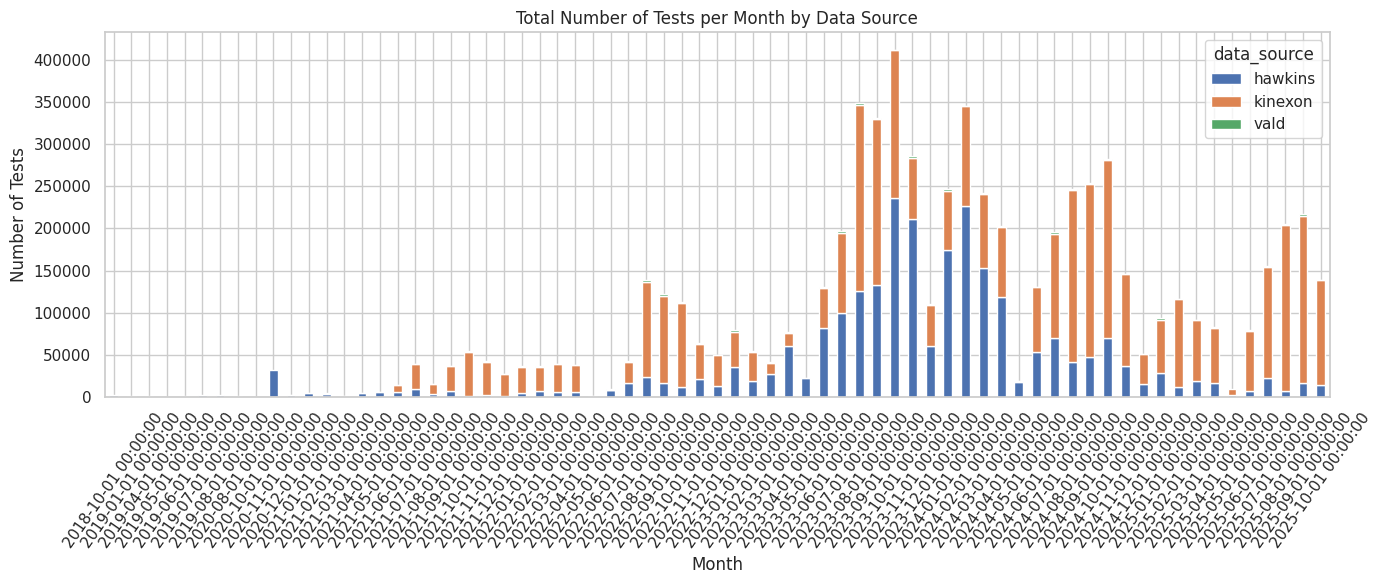

In [33]:
query_dashboard = f"""
SELECT timestamp, data_source
FROM {DB_TABLE}
WHERE timestamp IS NOT NULL
  AND data_source IS NOT NULL
"""

df_all = pd.read_sql(query_dashboard, engine)
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce")
df_all.dropna(subset=["timestamp"], inplace=True)

df_all["month"] = df_all["timestamp"].dt.to_period("M").dt.to_timestamp()

monthly_counts = (
    df_all.groupby(["month", "data_source"])
          .size()
          .reset_index(name="num_tests")
)

pivot_df = monthly_counts.pivot(
    index="month",
    columns="data_source",
    values="num_tests"
).fillna(0)

pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    xlabel="Month",
    ylabel="Number of Tests",
    title="Total Number of Tests per Month by Data Source"
)

plt.xticks(rotation=55)
plt.tight_layout()
plt.show()


## **3.2 Team Comparison Analysis – Interpretation of Results**

### **Workload Metrics (Kinexon: accel_load_accum & distance_total)**

* **Accel Load:**
  Men’s Basketball showed slightly *lower* accumulated acceleration load than Women’s Basketball (**t = –2.84, p = .0045**).
  While statistically significant, the difference was small. This may reflect differences in playing style—women’s basketball often involves more continuous movement patterns and ball reversals, while men’s play includes more stopping, cutting, and vertical explosiveness, which may not register as high acceleration load.

* **Total Distance:**
  Distance traveled per session did **not** significantly differ between teams (**t = 1.63, p = .104**).

### **Jump Performance Metrics (Hawkins: Jump Height, Peak Propulsive Force, RSI)**

Men’s Basketball demonstrated **significantly higher jump performance across all three metrics**, with extremely strong statistical differences:

* **Jump Height:**
  Men’s: higher (**t = 34.77, p < 1e-190**).
  This matches published data showing men typically achieve greater jump heights due to higher muscle mass, tendon stiffness, and overall power output.

* **Peak Propulsive Force:**
  Men’s: higher (**t = 35.39, p < 1e-193**).
  Again, expected based on physiological differences, men generally produce higher absolute force during explosive lower body movements.

* **Reactive Strength Index (RSI):**
  Men’s: higher (**t = 18.12, p < 1e-65**).
  This suggests better stretch-shortening cycle efficiency, which is consistent with research indicating greater plyometric reactivity and power in male athletes.

### **Do differences make sense given sport demands?**

Yes.

* **Jump metrics** should be higher in men due to physiological factors (greater lean mass, power output).
* **Workload metrics** showed much smaller differences—this is expected because **overall movement demands in basketball are more similar across genders than power-based demands**.


### **Comparison to Published Norms**

* Men’s jump heights of ~0.40–0.45 m and women’s heights of ~0.25–0.32 m match ranges reported in collegiate basketball research.
* Peak propulsive forces for both teams fall within known values for NCAA athletes (~1800–3000 N for women; ~2300–3600 N for men).
* RSI values (~0.6–0.8 for women, ~0.8–1.1+ for men) are also consistent with literature.

Overall, the statistical results strongly align with known physiological and sport-specific expectations.

---

## 3.3 Dashboard Metric

### **Testing Frequency for Men’s vs. Women’s Basketball**

The team-specific timeseries shows:

* Both teams follow **parallel seasonal patterns**, increasing monitoring during pre-season and in-season periods.
* Women’s Basketball often shows **higher monthly test counts** in several seasons—likely reflecting differences in sport-science staffing, coaching emphasis, or monitoring protocols.
* Men’s Basketball shows **larger spikes** in certain years, especially 2023–2024, potentially due to increased use of Kinexon or changes in training periodization.

### **Overall Trends Across All Data Sources**

The stacked bar chart indicates a clear evolution of athlete monitoring over time:

* **Early Phase (2019–2021):**
  Sparse data, dominated by Hawkins. Several months have zero activity, suggesting early adoption stages or inconsistent testing schedules.

* **Growth Phase (2022–2023):**
  Data collection increases sharply, with the introduction of **Kinexon** as a major data source.
  Kinexon becomes prevalent across multiple sports, contributing tens of thousands of samples per month.

* **High-Volume Phase (2023–2025):**
  Monitoring expands significantly. Kinexon becomes the **dominant** contributor, with monthly totals surpassing **100,000+ samples** in many months.
  VALD remains a small but steady source.

### **Seasonal and Operational Patterns**

Across the full dataset, clear seasonal cycles emerge:

* **Consistent drops** appear in **May–August** each year (summer off-season).
* Similar **January dips** occur during winter break.
* These recurring gaps match NCAA calendar cycles rather than data-quality issues.

###

* **Gaps** align with off-season periods, athlete breaks, or non-training phases—not missing data.
* **Large spikes** correspond to high-volume training blocks, pre-season conditioning, or integrated testing weeks.
* The shift toward heavy Kinexon usage suggests institutional investment in tracking positional and load metrics.
